# AIC OCR Phase 1 — Optimized GPU Pipeline

Pipeline:

```text
Keyframe
→ PP-OCRv6_medium_det phát hiện chữ theo batch
→ CPU perspective crop song song
→ chỉ upscale crop nhỏ
→ gom crop của nhiều frame
→ VietOCR nhận dạng theo batch lớn
→ ghép theo thứ tự đọc
→ ghi JSONL checkpoint liên tục
```

Output giữ đúng schema đơn giản:

```json
{
  "frame_id": "001",
  "shot_id": "001",
  "video_id": "L21_V001",
  "OCR": "..."
}
```

Notebook dùng được cho:

- Kaggle T4;
- Google Colab T4, L4 hoặc A100;
- một video folder;
- dataset mới có nhiều thư mục video;
- demo giới hạn frame hoặc chạy toàn bộ;
- tiếp tục từ checkpoint sau khi runtime bị ngắt.

## Cách chạy

1. Bật GPU.
2. Chạy cell cài đặt một lần.
3. Restart session/runtime.
4. Chỉnh duy nhất cell **Cấu hình**.
5. Chạy từ cell kiểm tra GPU đến hết.


In [ ]:
# 1. CÀI THƯ VIỆN
# Chạy một lần, sau đó Restart Session / Restart Runtime.

!nvidia-smi

!pip uninstall -y -q paddlepaddle paddlepaddle-gpu paddleocr paddlex

# Wheel CUDA 12.6 đang dùng ổn trên Kaggle hiện tại.
!python -m pip install -q --no-deps paddlepaddle-gpu==3.3.0 \
    -i https://www.paddlepaddle.org.cn/packages/stable/cu126/

!python -m pip install -q \
    paddleocr==3.7.0 \
    vietocr==0.3.13 \
    opencv-python-headless \
    pandas \
    pillow \
    matplotlib \
    tqdm

print("Cài đặt xong. Hãy Restart Session/Runtime rồi chạy từ cell 2.")


In [17]:
# 2. CẤU HÌNH DUY NHẤT CẦN CHỈNH KHI ĐỔI DATASET

from pathlib import Path

# Có thể là:
# - một folder video: .../L21_V001
# - folder chứa nhiều video: .../keyframes
# - root dataset mới có nhiều cấp thư mục
INPUT_ROOT = Path(
    "/kaggle/input/datasets/nguynnc/aic2025/"
    "Keyframes_L21/keyframes"
)

# False: chỉ đọc ảnh trực tiếp trong INPUT_ROOT.
# True : quét tất cả thư mục con của INPUT_ROOT.
RECURSIVE = True

# "demo": lấy một số frame cách đều.
# "full": chạy toàn bộ ảnh tìm thấy.
RUN_MODE = "full"
DEMO_MAX_FRAMES = 50

# Tên riêng cho lần chạy. Đổi tên khi chuyển dataset để không trộn checkpoint.
RUN_NAME = "KF_l21"

# Tiếp tục từ JSONL đã tồn tại.
RESUME = True

# Chia dataset thành nhiều shard khi cần chạy nhiều phiên độc lập.
# Bình thường giữ 1 và 0.
NUM_SHARDS = 1
SHARD_INDEX = 0

# GPU muốn dùng. Với một runtime thông thường giữ 0.
GPU_ID = 0

# Model VietOCR: "vgg_transformer" ưu tiên độ chính xác;
# "vgg_seq2seq" nhanh hơn.
VIETOCR_MODEL = "vgg_transformer"

# Chỉ tạo biến thể upscale khi crop thấp hơn ngưỡng này.
SMALL_CROP_HEIGHT = 42
UPSCALE_TARGET_HEIGHT = 64

# Ngưỡng lọc.
MIN_REC_CONFIDENCE = 0.20
MIN_CROP_WIDTH = 12
MIN_CROP_HEIGHT = 6

# Giữ một số frame đầu để trực quan hóa, không ảnh hưởng output.
KEEP_DEBUG_FRAMES = 5

# Có thể đặt số cụ thể để ghi đè cấu hình tự động.
# None = tự chọn theo T4/A100.
FRAME_BATCH_SIZE_OVERRIDE = None
REC_BATCH_SIZE_OVERRIDE = None
CPU_WORKERS_OVERRIDE = None


In [2]:
# 3. KIỂM TRA GPU, TỰ CHỌN PROFILE T4/A100 VÀ KHAI BÁO OUTPUT

import os
import warnings
from pathlib import Path

os.environ["PADDLE_PDX_DISABLE_MODEL_SOURCE_CHECK"] = "True"
os.environ["PADDLE_PDX_MODEL_SOURCE"] = "bos"

warnings.filterwarnings(
    "ignore",
    message="invalid value encountered in divide",
    category=RuntimeWarning,
    module=r"vietocr\.tool\.translate",
)

import cv2
import paddle
import torch

if not paddle.device.is_compiled_with_cuda():
    raise RuntimeError("Paddle chưa nhận GPU.")

if not torch.cuda.is_available():
    raise RuntimeError("PyTorch chưa nhận GPU.")

if GPU_ID >= torch.cuda.device_count():
    raise ValueError(
        f"GPU_ID={GPU_ID}, nhưng runtime chỉ có "
        f"{torch.cuda.device_count()} GPU."
    )

paddle.set_device(f"gpu:{GPU_ID}")
torch.cuda.set_device(GPU_ID)

torch.backends.cudnn.benchmark = True
torch.set_grad_enabled(False)

# Tránh OpenCV tự tạo quá nhiều thread khi đã dùng ThreadPoolExecutor.
cv2.setNumThreads(1)

GPU_NAME = torch.cuda.get_device_name(GPU_ID)
GPU_NAME_UPPER = GPU_NAME.upper()
CPU_COUNT = os.cpu_count() or 2

if "A100" in GPU_NAME_UPPER:
    AUTO_FRAME_BATCH_SIZE = 20
    AUTO_REC_BATCH_SIZE = 192
    AUTO_CPU_WORKERS = min(8, CPU_COUNT)
elif "L4" in GPU_NAME_UPPER:
    AUTO_FRAME_BATCH_SIZE = 12
    AUTO_REC_BATCH_SIZE = 96
    AUTO_CPU_WORKERS = min(6, CPU_COUNT)
elif "T4" in GPU_NAME_UPPER:
    AUTO_FRAME_BATCH_SIZE = 8
    AUTO_REC_BATCH_SIZE = 64
    AUTO_CPU_WORKERS = min(4, CPU_COUNT)
else:
    AUTO_FRAME_BATCH_SIZE = 6
    AUTO_REC_BATCH_SIZE = 48
    AUTO_CPU_WORKERS = min(4, CPU_COUNT)

FRAME_BATCH_SIZE = (
    FRAME_BATCH_SIZE_OVERRIDE
    if FRAME_BATCH_SIZE_OVERRIDE is not None
    else AUTO_FRAME_BATCH_SIZE
)

REC_BATCH_SIZE = (
    REC_BATCH_SIZE_OVERRIDE
    if REC_BATCH_SIZE_OVERRIDE is not None
    else AUTO_REC_BATCH_SIZE
)

CPU_WORKERS = (
    CPU_WORKERS_OVERRIDE
    if CPU_WORKERS_OVERRIDE is not None
    else AUTO_CPU_WORKERS
)

if Path("/kaggle/working").exists():
    WORK_ROOT = Path("/kaggle/working")
else:
    WORK_ROOT = Path("/content")

OUTPUT_DIR = WORK_ROOT / "aic_ocr_outputs" / RUN_NAME
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

JSONL_PATH = OUTPUT_DIR / "ocr_results.jsonl"
JSON_PATH = OUTPUT_DIR / "ocr_results.json"
ERROR_PATH = OUTPUT_DIR / "ocr_errors.jsonl"

print("GPU                   :", GPU_NAME)
print("Số GPU                :", torch.cuda.device_count())
print("Paddle device         :", paddle.device.get_device())
print("FRAME_BATCH_SIZE      :", FRAME_BATCH_SIZE)
print("REC_BATCH_SIZE        :", REC_BATCH_SIZE)
print("CPU_WORKERS           :", CPU_WORKERS)
print("OUTPUT_DIR            :", OUTPUT_DIR)


/usr/local/lib/python3.12/dist-packages/paddle/utils/cpp_extension/extension_utils.py:712: UserWarning: No ccache found. Please be aware that recompiling all source files may be required. You can download and install ccache from: https://github.com/ccache/ccache/blob/master/doc/INSTALL.md
  warnings.warn(warning_message)


GPU                   : Tesla T4
Số GPU                : 2
Paddle device         : gpu:0
FRAME_BATCH_SIZE      : 8
REC_BATCH_SIZE        : 64
CPU_WORKERS           : 4
OUTPUT_DIR            : /kaggle/working/aic_ocr_outputs/aic2025_L21_V001


In [18]:
# 4. QUÉT DATASET VÀ TẠO INDEXING RECORDS

import os
import numpy as np

IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".webp", ".bmp"}

if not INPUT_ROOT.exists():
    raise FileNotFoundError(f"Không tìm thấy INPUT_ROOT: {INPUT_ROOT}")


def natural_frame_key(path: Path):
    stem = path.stem
    return int(stem) if stem.isdigit() else stem.lower()


def scan_images(root: Path, recursive: bool) -> list[Path]:
    paths = []

    if recursive:
        for current_root, _, filenames in os.walk(root):
            current_root = Path(current_root)

            for filename in filenames:
                path = current_root / filename

                if path.suffix.lower() in IMAGE_EXTENSIONS:
                    paths.append(path)
    else:
        with os.scandir(root) as entries:
            for entry in entries:
                if not entry.is_file():
                    continue

                path = Path(entry.path)

                if path.suffix.lower() in IMAGE_EXTENSIONS:
                    paths.append(path)

    paths.sort(
        key=lambda path: (
            path.parent.name.lower(),
            natural_frame_key(path),
        )
    )

    return paths


all_paths = scan_images(INPUT_ROOT, RECURSIVE)

if not all_paths:
    raise RuntimeError(f"Không tìm thấy ảnh trong: {INPUT_ROOT}")

all_records = [
    {
        "img_path": str(path),
        "shot_id": path.stem,
        "video_id": path.parent.name,
        "index": path.stem,
    }
    for path in all_paths
]

# Chia shard trước khi lấy demo.
all_records = all_records[SHARD_INDEX::NUM_SHARDS]

if RUN_MODE.lower() == "demo":
    demo_count = min(DEMO_MAX_FRAMES, len(all_records))

    selected_indices = np.linspace(
        0,
        len(all_records) - 1,
        demo_count,
        dtype=int,
    )

    indexing_records = [
        all_records[index]
        for index in selected_indices
    ]

elif RUN_MODE.lower() == "full":
    indexing_records = all_records

else:
    raise ValueError("RUN_MODE phải là 'demo' hoặc 'full'.")

print("Tổng ảnh tìm thấy     :", len(all_paths))
print("Số record trong shard :", len(all_records))
print("Số frame sẽ OCR       :", len(indexing_records))
print("RUN_MODE              :", RUN_MODE)
print("NUM_SHARDS/SHARD      :", NUM_SHARDS, SHARD_INDEX)
print("Record đầu            :", indexing_records[0])
print("Record cuối           :", indexing_records[-1])


Tổng ảnh tìm thấy     : 7800
Số record trong shard : 7800
Số frame sẽ OCR       : 7800
RUN_MODE              : full
NUM_SHARDS/SHARD      : 1 0
Record đầu            : {'img_path': '/kaggle/input/datasets/nguynnc/aic2025/Keyframes_L21/keyframes/L21_V001/001.jpg', 'shot_id': '001', 'video_id': 'L21_V001', 'index': '001'}
Record cuối           : {'img_path': '/kaggle/input/datasets/nguynnc/aic2025/Keyframes_L21/keyframes/L21_V031/285.jpg', 'shot_id': '285', 'video_id': 'L21_V031', 'index': '285'}


In [4]:
# 5. KHỞI TẠO PP-OCRv6 DETECTOR VÀ VIETOCR

from paddlex import create_model
from vietocr.tool.config import Cfg
from vietocr.tool.predictor import Predictor

detector = create_model(
    model_name="PP-OCRv6_medium_det",
    device=f"gpu:{GPU_ID}",
)

vietocr_config = Cfg.load_config_from_name(VIETOCR_MODEL)
vietocr_config["device"] = f"cuda:{GPU_ID}"
vietocr_config["cnn"]["pretrained"] = False
vietocr_config["predictor"]["beamsearch"] = False

vietocr_predictor = Predictor(vietocr_config)

print("Detector   : PP-OCRv6_medium_det")
print("Recognizer :", VIETOCR_MODEL)
print("Models đã sẵn sàng.")


/usr/local/lib/python3.12/dist-packages/gdown/__init__.py:3: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
Connectivity check to the model hoster has been skipped because `PADDLE_PDX_DISABLE_MODEL_SOURCE_CHECK` is enabled.
Using official model (PP-OCRv6_medium_det), the model files will be automatically downloaded and saved in `/root/.paddlex/official_models/PP-OCRv6_medium_det`.
Connecting to https://paddle-model-ecology.bj.bcebos.com/paddlex/official_inference_model/paddle3.0.0/PP-OCRv6_medium_det_infer.tar ...
[==================================================] 100.00%
Extracting PP-OCRv6_medium_det_infer.tar
[==================================================] 100.00%
/usr/local/lib/python3.12/dist-packages/torch/nn/modules/transformer.py:144: UserWarning: enable_ne

Detector   : PP-OCRv6_medium_det
Recognizer : vgg_transformer
Models đã sẵn sàng.


In [5]:
# 6. HÀM DETECTION, PERSPECTIVE CROP VÀ CROP VARIANTS

from typing import Any
import cv2
import numpy as np
from PIL import Image

DET_LIMIT_SIDE_LEN = 1920
DET_THRESH = 0.25
DET_BOX_THRESH = 0.45
DET_UNCLIP_RATIO = 1.5


def to_python(value: Any):
    return value.tolist() if hasattr(value, "tolist") else value


def result_to_dict(result: Any) -> dict:
    data = result.json if hasattr(result, "json") else result

    if callable(data):
        data = data()

    if not isinstance(data, dict):
        return {}

    return data.get("res", data)


def parse_detection_result(result: Any) -> tuple[list, list]:
    data = result_to_dict(result)

    polygons = to_python(data.get("dt_polys", [])) or []
    scores = to_python(data.get("dt_scores", [])) or []

    return polygons, scores


def detection_input_path(result: Any) -> str:
    data = result_to_dict(result)

    value = (
        data.get("input_path")
        or data.get("input")
        or data.get("img_path")
        or ""
    )

    return str(value)


def order_quad_points(points: np.ndarray) -> np.ndarray:
    pts = np.asarray(points, dtype=np.float32).reshape(4, 2)
    ordered = np.zeros((4, 2), dtype=np.float32)

    sums = pts.sum(axis=1)
    diffs = np.diff(pts, axis=1).reshape(-1)

    ordered[0] = pts[np.argmin(sums)]
    ordered[2] = pts[np.argmax(sums)]
    ordered[1] = pts[np.argmin(diffs)]
    ordered[3] = pts[np.argmax(diffs)]

    return ordered


def perspective_crop(
    image_bgr: np.ndarray,
    polygon,
    border_ratio: float = 0.08,
):
    points = order_quad_points(
        np.asarray(polygon, dtype=np.float32)
    )

    top_left, top_right, bottom_right, bottom_left = points

    crop_width = int(
        round(
            max(
                np.linalg.norm(top_right - top_left),
                np.linalg.norm(bottom_right - bottom_left),
            )
        )
    )

    crop_height = int(
        round(
            max(
                np.linalg.norm(bottom_right - top_right),
                np.linalg.norm(bottom_left - top_left),
            )
        )
    )

    if (
        crop_width < MIN_CROP_WIDTH
        or crop_height < MIN_CROP_HEIGHT
    ):
        return None

    destination = np.array(
        [
            [0, 0],
            [crop_width - 1, 0],
            [crop_width - 1, crop_height - 1],
            [0, crop_height - 1],
        ],
        dtype=np.float32,
    )

    matrix = cv2.getPerspectiveTransform(
        points,
        destination,
    )

    crop = cv2.warpPerspective(
        image_bgr,
        matrix,
        (crop_width, crop_height),
        flags=cv2.INTER_CUBIC,
        borderMode=cv2.BORDER_REPLICATE,
    )

    if crop.shape[0] > crop.shape[1] * 1.5:
        crop = cv2.rotate(
            crop,
            cv2.ROTATE_90_CLOCKWISE,
        )

    border = max(
        2,
        int(round(crop.shape[0] * border_ratio)),
    )

    crop = cv2.copyMakeBorder(
        crop,
        border,
        border,
        border,
        border,
        borderType=cv2.BORDER_REPLICATE,
    )

    crop_rgb = cv2.cvtColor(
        crop,
        cv2.COLOR_BGR2RGB,
    )

    return Image.fromarray(crop_rgb)


def create_crop_variants(crop: Image.Image):
    crop = crop.convert("RGB")

    # Crop đủ lớn chỉ chạy một lần để tiết kiệm GPU.
    if crop.height >= SMALL_CROP_HEIGHT:
        return [("original", crop)]

    scale = UPSCALE_TARGET_HEIGHT / max(crop.height, 1)

    target_width = max(
        16,
        int(round(crop.width * scale)),
    )

    upscaled = crop.resize(
        (target_width, UPSCALE_TARGET_HEIGHT),
        Image.Resampling.LANCZOS,
    )

    # Crop nhỏ dùng bản upscale; không nhân đôi inference không cần thiết.
    return [("upscale", upscaled)]


In [6]:
# 7. HÀM CHỌN KẾT QUẢ VIETOCR VÀ XỬ LÝ OOM TỰ ĐỘNG

import re
import numpy as np
import torch


def confidence_to_float(value) -> float:
    if value is None:
        return 0.0

    try:
        array = np.asarray(value, dtype=float)

        if array.size == 0:
            return 0.0

        finite = array[np.isfinite(array)]

        if finite.size == 0:
            return 0.0

        return float(finite.mean())

    except Exception:
        try:
            value = float(value)
            return value if np.isfinite(value) else 0.0
        except Exception:
            return 0.0


def text_validity_ratio(text: str) -> float:
    text = str(text).strip()

    if not text:
        return 0.0

    valid_count = sum(
        character.isalnum()
        or character.isspace()
        or character in ".,:;!?%+-_/()'\"&"
        for character in text
    )

    return valid_count / max(len(text), 1)


def candidate_score(text: str, confidence: float) -> float:
    if not text.strip():
        return -1.0

    return (
        confidence * 0.90
        + text_validity_ratio(text) * 0.10
    )


def predict_vietocr_recursive(images):
    """
    Nhận dạng một batch. Nếu GPU hết VRAM, tự chia đôi batch.
    """
    if not images:
        return [], []

    try:
        with torch.inference_mode():
            texts, probabilities = (
                vietocr_predictor.predict_batch(
                    images,
                    return_prob=True,
                )
            )

        return list(texts), list(probabilities)

    except RuntimeError as error:
        message = str(error).lower()

        if (
            "out of memory" not in message
            and "cuda" not in message
        ):
            raise

        torch.cuda.empty_cache()

        if len(images) == 1:
            try:
                with torch.inference_mode():
                    text, probability = (
                        vietocr_predictor.predict(
                            images[0],
                            return_prob=True,
                        )
                    )

                return [text], [probability]

            except Exception:
                return [""], [0.0]

        middle = len(images) // 2

        left_texts, left_probs = (
            predict_vietocr_recursive(
                images[:middle]
            )
        )

        right_texts, right_probs = (
            predict_vietocr_recursive(
                images[middle:]
            )
        )

        return (
            left_texts + right_texts,
            left_probs + right_probs,
        )


def predict_vietocr_in_chunks(images):
    all_texts = []
    all_probabilities = []

    for start in range(0, len(images), REC_BATCH_SIZE):
        chunk = images[start:start + REC_BATCH_SIZE]

        texts, probabilities = (
            predict_vietocr_recursive(chunk)
        )

        all_texts.extend(texts)
        all_probabilities.extend(probabilities)

    return all_texts, all_probabilities


In [7]:
# 8. BATCH PIPELINE: GPU DETECT → CPU CROP SONG SONG → GPU VIETOCR

from concurrent.futures import ThreadPoolExecutor
from pathlib import Path
import numpy as np


def box_reading_key(instance: dict):
    polygon = np.asarray(
        instance["bbox"],
        dtype=float,
    ).reshape(-1, 2)

    center_y = float(polygon[:, 1].mean())
    min_x = float(polygon[:, 0].min())

    return center_y, min_x


def run_detection_batch(records):
    paths = [record["img_path"] for record in records]

    outputs = list(
        detector.predict(
            paths,
            batch_size=FRAME_BATCH_SIZE,
            limit_side_len=DET_LIMIT_SIDE_LEN,
            limit_type="max",
            thresh=DET_THRESH,
            box_thresh=DET_BOX_THRESH,
            unclip_ratio=DET_UNCLIP_RATIO,
        )
    )

    # Ưu tiên ánh xạ bằng input_path.
    by_path = {}

    for output in outputs:
        path = detection_input_path(output)

        if path:
            by_path[str(Path(path))] = output

    mapped = []

    for index, record in enumerate(records):
        normalized_path = str(Path(record["img_path"]))

        output = by_path.get(normalized_path)

        # Fallback theo thứ tự trả về.
        if output is None and index < len(outputs):
            output = outputs[index]

        mapped.append(output)

    return mapped


def prepare_frame_package(args):
    record, detection_result = args

    if detection_result is None:
        return {
            "record": record,
            "crops": [],
            "error": None,
        }

    image_bgr = cv2.imread(record["img_path"])

    if image_bgr is None:
        return {
            "record": record,
            "crops": [],
            "error": "Không đọc được ảnh",
        }

    polygons, detection_scores = (
        parse_detection_result(
            detection_result
        )
    )

    crops = []

    for polygon_index, polygon in enumerate(polygons):
        crop = perspective_crop(
            image_bgr,
            polygon,
        )

        if crop is None:
            continue

        variants = create_crop_variants(crop)

        crops.append({
            "polygon": polygon,
            "det_confidence": (
                float(detection_scores[polygon_index])
                if polygon_index < len(detection_scores)
                else None
            ),
            "variants": variants,
        })

    return {
        "record": record,
        "crops": crops,
        "error": None,
    }


def process_record_batch(records):
    detection_results = run_detection_batch(
        records
    )

    with ThreadPoolExecutor(
        max_workers=CPU_WORKERS
    ) as executor:
        packages = list(
            executor.map(
                prepare_frame_package,
                zip(records, detection_results),
            )
        )

    all_variant_images = []
    crop_references = []

    for frame_index, package in enumerate(packages):
        for crop in package["crops"]:
            start = len(all_variant_images)

            variant_names = []

            for variant_name, variant_image in crop["variants"]:
                variant_names.append(variant_name)
                all_variant_images.append(variant_image)

            crop_references.append({
                "frame_index": frame_index,
                "polygon": crop["polygon"],
                "det_confidence": crop["det_confidence"],
                "start": start,
                "count": len(crop["variants"]),
                "variant_names": variant_names,
            })

    if all_variant_images:
        all_texts, all_probabilities = (
            predict_vietocr_in_chunks(
                all_variant_images
            )
        )
    else:
        all_texts, all_probabilities = [], []

    frame_instances = {
        index: []
        for index in range(len(packages))
    }

    for reference in crop_references:
        start = reference["start"]
        end = start + reference["count"]

        candidates = []

        for variant_name, text, probability in zip(
            reference["variant_names"],
            all_texts[start:end],
            all_probabilities[start:end],
        ):
            clean_text = re.sub(
                r"\s+",
                " ",
                str(text),
            ).strip()

            confidence = confidence_to_float(
                probability
            )

            if confidence < MIN_REC_CONFIDENCE:
                continue

            candidates.append({
                "text": clean_text,
                "confidence": confidence,
                "variant": variant_name,
                "score": candidate_score(
                    clean_text,
                    confidence,
                ),
            })

        if not candidates:
            continue

        best = max(
            candidates,
            key=lambda candidate: candidate["score"],
        )

        if not best["text"]:
            continue

        frame_instances[
            reference["frame_index"]
        ].append({
            "text": best["text"],
            "bbox": to_python(reference["polygon"]),
            "det_confidence": reference["det_confidence"],
            "rec_confidence": best["confidence"],
            "variant": best["variant"],
        })

    output_records = []
    debug_batch = []
    errors = []

    for frame_index, package in enumerate(packages):
        record = package["record"]
        instances = frame_instances[frame_index]

        instances.sort(key=box_reading_key)

        merged_text = " | ".join(
            instance["text"]
            for instance in instances
        )

        output_records.append({
            "frame_id": str(record["index"]),
            "shot_id": str(record["shot_id"]),
            "video_id": str(record["video_id"]),
            "OCR": merged_text,
        })

        debug_batch.append({
            **record,
            "OCR": merged_text,
            "instances": instances,
        })

        if package["error"]:
            errors.append({
                "img_path": record["img_path"],
                "error": package["error"],
            })

    return output_records, debug_batch, errors


In [ ]:
# 9. CHECKPOINT, RESUME VÀ CHẠY PIPELINE

import json
import time
from tqdm.auto import tqdm


def record_key(record):
    return (
        str(record["video_id"]),
        str(record["frame_id"]),
    )


def load_completed_keys(jsonl_path: Path):
    completed = set()

    if not jsonl_path.exists():
        return completed

    with jsonl_path.open(
        "r",
        encoding="utf-8",
    ) as file:
        for line in file:
            line = line.strip()

            if not line:
                continue

            try:
                record = json.loads(line)
                completed.add(record_key(record))
            except Exception:
                continue

    return completed


if RESUME:
    completed_keys = load_completed_keys(
        JSONL_PATH
    )
else:
    completed_keys = set()

    for path in [
        JSONL_PATH,
        JSON_PATH,
        ERROR_PATH,
    ]:
        if path.exists():
            path.unlink()

pending_records = [
    record
    for record in indexing_records
    if (
        str(record["video_id"]),
        str(record["index"]),
    )
    not in completed_keys
]

print("Đã hoàn thành trước đó :", len(completed_keys))
print("Còn phải xử lý         :", len(pending_records))

debug_records = []
run_processed = 0
run_text_frames = 0
run_errors = 0

start_time = time.perf_counter()

with JSONL_PATH.open(
    "a",
    encoding="utf-8",
    buffering=1,
) as output_file:

    error_file = ERROR_PATH.open(
        "a",
        encoding="utf-8",
        buffering=1,
    )

    try:
        progress = tqdm(
            range(
                0,
                len(pending_records),
                FRAME_BATCH_SIZE,
            ),
            desc="Optimized OCR",
        )

        for start in progress:
            batch_records = pending_records[
                start:start + FRAME_BATCH_SIZE
            ]

            try:
                (
                    batch_outputs,
                    batch_debug,
                    batch_errors,
                ) = process_record_batch(
                    batch_records
                )

            except Exception as error:
                batch_outputs = [
                    {
                        "frame_id": str(record["index"]),
                        "shot_id": str(record["shot_id"]),
                        "video_id": str(record["video_id"]),
                        "OCR": "",
                    }
                    for record in batch_records
                ]

                batch_debug = []

                batch_errors = [
                    {
                        "img_path": record["img_path"],
                        "error": repr(error),
                    }
                    for record in batch_records
                ]

                torch.cuda.empty_cache()

            for record in batch_outputs:
                output_file.write(
                    json.dumps(
                        record,
                        ensure_ascii=False,
                    )
                    + "\n"
                )

            for error_record in batch_errors:
                error_file.write(
                    json.dumps(
                        error_record,
                        ensure_ascii=False,
                    )
                    + "\n"
                )

            if len(debug_records) < KEEP_DEBUG_FRAMES:
                remaining = (
                    KEEP_DEBUG_FRAMES
                    - len(debug_records)
                )

                debug_records.extend(
                    batch_debug[:remaining]
                )

            run_processed += len(batch_outputs)

            run_text_frames += sum(
                bool(record["OCR"].strip())
                for record in batch_outputs
            )

            run_errors += len(batch_errors)

            elapsed = time.perf_counter() - start_time
            seconds_per_frame = (
                elapsed / max(run_processed, 1)
            )

            progress.set_postfix({
                "frame": run_processed,
                "s/frame": f"{seconds_per_frame:.3f}",
                "text": run_text_frames,
                "errors": run_errors,
            })

    finally:
        error_file.close()

elapsed = time.perf_counter() - start_time

print("\n===== KẾT QUẢ LẦN CHẠY NÀY =====")
print("Frame đã xử lý      :", run_processed)
print("Frame có text       :", run_text_frames)
print("Số lỗi              :", run_errors)
print(f"Tổng thời gian      : {elapsed:.2f} giây")
print(
    f"Trung bình/frame    : "
    f"{elapsed / max(run_processed, 1):.3f} giây"
)
print("Checkpoint JSONL    :", JSONL_PATH)


Đã hoàn thành trước đó : 307
Còn phải xử lý         : 7493


Optimized OCR:   0%|          | 0/937 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [15]:
# 10. ĐỌC KẾT QUẢ, LOẠI TRÙNG VÀ XUẤT JSON HOÀN CHỈNH

import json
import pandas as pd


def load_unique_results(jsonl_path: Path):
    unique = {}

    with jsonl_path.open(
        "r",
        encoding="utf-8",
    ) as file:
        for line in file:
            line = line.strip()

            if not line:
                continue

            record = json.loads(line)
            unique[record_key(record)] = record

    records = list(unique.values())

    records.sort(
        key=lambda record: (
            str(record["video_id"]),
            (
                int(record["frame_id"])
                if str(record["frame_id"]).isdigit()
                else str(record["frame_id"])
            ),
        )
    )

    return records


output_records = load_unique_results(
    JSONL_PATH
)

with JSON_PATH.open(
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        output_records,
        file,
        ensure_ascii=False,
        indent=2,
    )

print("Tổng record trong output:", len(output_records))
print(
    "Record có OCR          :",
    sum(
        bool(record["OCR"].strip())
        for record in output_records
    ),
)
print("JSONL:", JSONL_PATH)
print("JSON :", JSON_PATH)

display(
    pd.DataFrame(output_records).head(30)
)


Tổng record trong output: 307
Record có OCR          : 307
JSONL: /kaggle/working/aic_ocr_outputs/aic2025_L21_V001/ocr_results.jsonl
JSON : /kaggle/working/aic_ocr_outputs/aic2025_L21_V001/ocr_results.json


,frame_id,shot_id,video_id,OCR
0,001,001,L21_V001,HTM | HD | 06:30:11 | giây
1,002,002,L21_V001,HTVX | HD | 06:30:14 | giây
2,003,003,L21_V001,HM | HD | 06:30:19 | 16 | OBVES | MALANH | VIN...
3,004,004,L21_V001,HTM2 | HP | 06:30:22
4,005,005,L21_V001,HTM | HD | 06:30:24 | noning
5,006,006,L21_V001,Hing | 06:30:28 | TINCHÍNH | giây | TÌNH TRẠNG...
6,007,007,L21_V001,HTV | HD | 06:30:34 | TINCHÍNH | giây | TRÁI T...
7,008,008,L21_V001,HTMX | HD | 06:30:46
8,009,009,L21_V001,MINH | 06:30:48
9,010,010,L21_V001,HTM | HD | 06:30:55


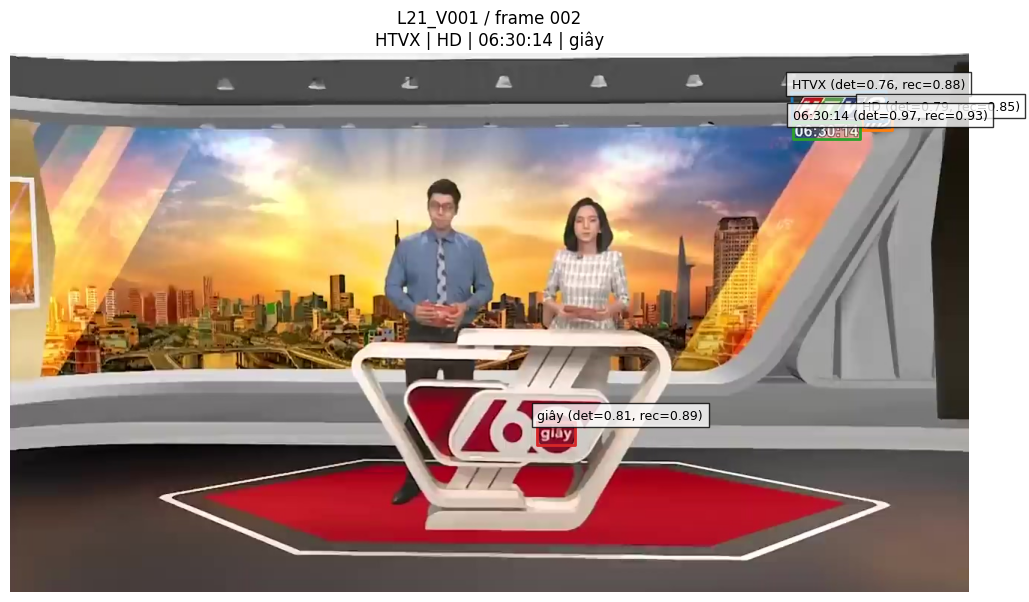

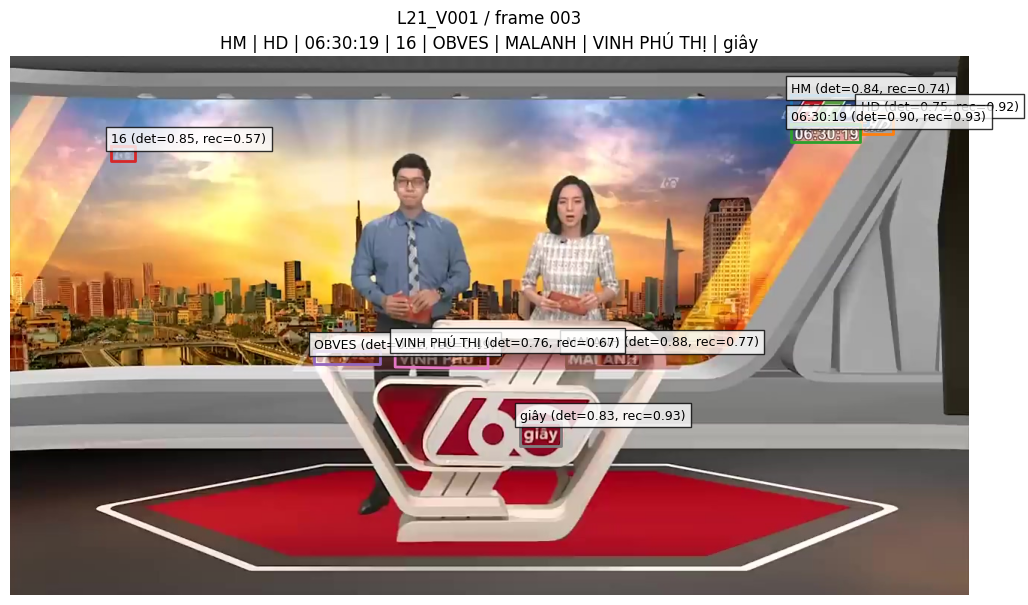

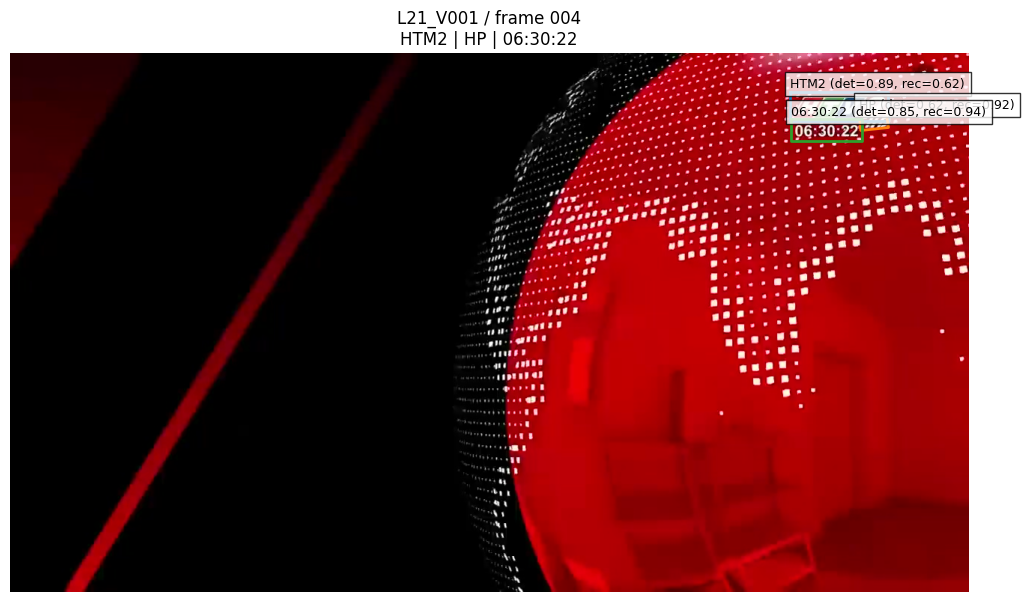

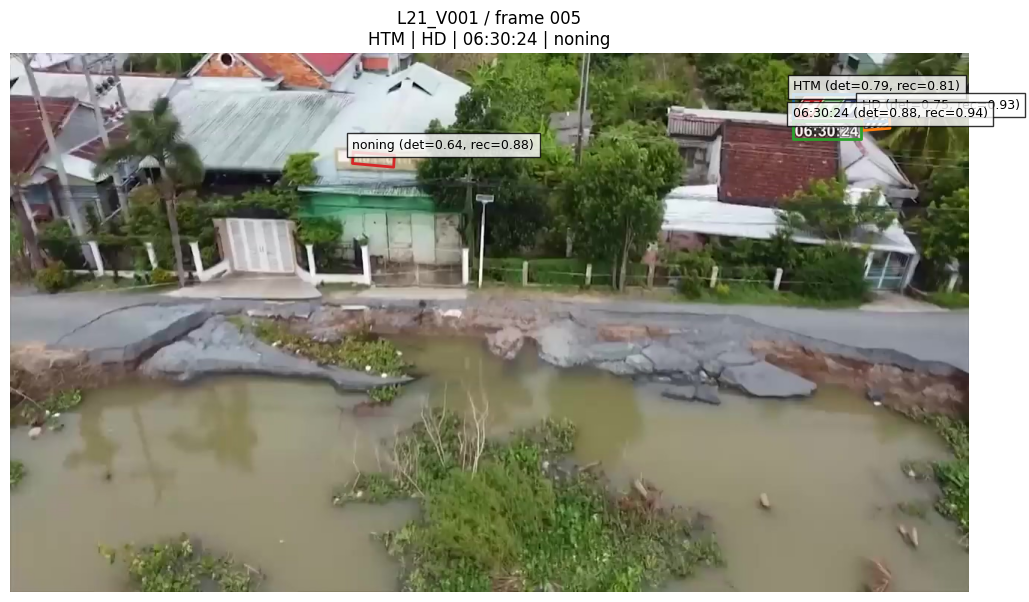

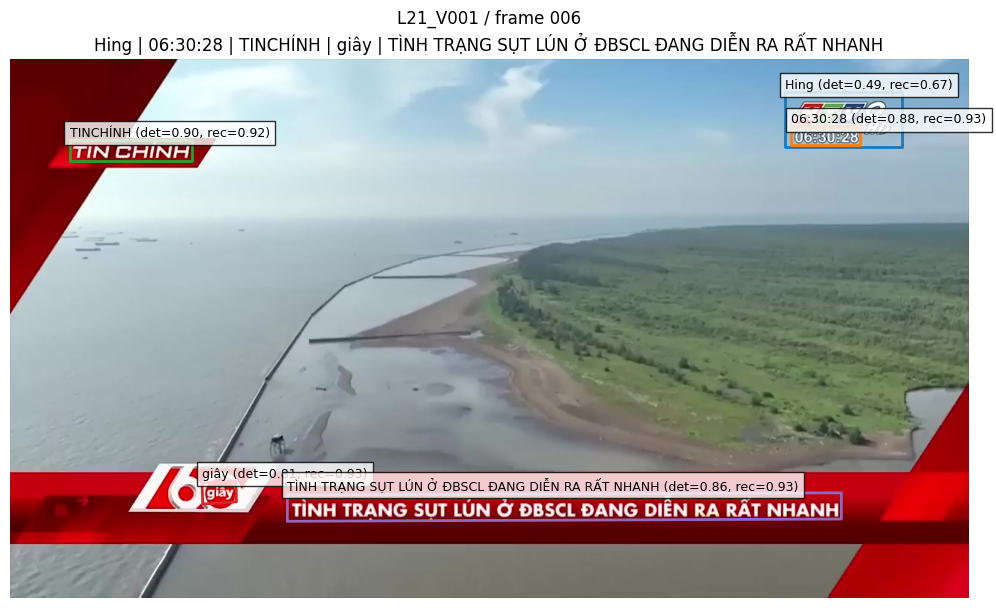

In [16]:
# 11. HIỂN THỊ MỘT SỐ FRAME VÀ BBOX ĐỂ KIỂM TRA

import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

for record in debug_records:
    image = np.array(
        Image.open(record["img_path"]).convert("RGB")
    )

    figure, axis = plt.subplots(
        figsize=(15, 7)
    )

    axis.imshow(image)
    axis.axis("off")

    axis.set_title(
        f'{record["video_id"]} / '
        f'frame {record["index"]}\n'
        f'{record["OCR"] or "(không có OCR)"}'
    )

    for instance in record["instances"]:
        polygon = np.asarray(
            instance["bbox"],
            dtype=float,
        ).reshape(-1, 2)

        closed_polygon = np.vstack([
            polygon,
            polygon[0],
        ])

        axis.plot(
            closed_polygon[:, 0],
            closed_polygon[:, 1],
            linewidth=2,
        )

        x = float(polygon[:, 0].min())
        y = float(polygon[:, 1].min())

        det_confidence = instance[
            "det_confidence"
        ]

        det_text = (
            f"{det_confidence:.2f}"
            if det_confidence is not None
            else "n/a"
        )

        axis.text(
            x,
            max(0, y - 5),
            (
                f'{instance["text"]} '
                f'(det={det_text}, '
                f'rec={instance["rec_confidence"]:.2f})'
            ),
            fontsize=9,
            bbox={
                "facecolor": "white",
                "alpha": 0.8,
            },
        )

    plt.show()


## Dùng trực tiếp với dataset mới

Chỉ cần chỉnh cell **Cấu hình**.

### Dataset là một folder video

```python
INPUT_ROOT = Path("/content/new_dataset/video_001")
RECURSIVE = False
RUN_MODE = "full"
RUN_NAME = "new_dataset_video_001"
```

### Dataset chứa nhiều folder video

```python
INPUT_ROOT = Path("/content/new_dataset/keyframes")
RECURSIVE = True
RUN_MODE = "full"
RUN_NAME = "new_dataset_all"
```

`video_id` được lấy từ tên folder chứa ảnh.  
`frame_id`, `shot_id` và `index` được lấy từ tên file ảnh.

### Profile đề xuất

| GPU | Frame batch | VietOCR batch |
|---|---:|---:|
| T4 | 8 | 64 |
| L4 | 12 | 96 |
| A100 | 20 | 192 |

Notebook tự chọn các giá trị này. Khi gặp CUDA out-of-memory, hàm recognition tự chia nhỏ batch. Nếu detector hết VRAM, giảm:

```python
FRAME_BATCH_SIZE_OVERRIDE = 4
```

### Chạy nhiều phiên

Chia dữ liệu thành hai phần:

Phiên 1:

```python
NUM_SHARDS = 2
SHARD_INDEX = 0
```

Phiên 2:

```python
NUM_SHARDS = 2
SHARD_INDEX = 1
```

Mỗi shard cần `RUN_NAME` khác nhau. Sau đó có thể nối hai file JSONL.
